# EV Charging Station Site Suitability Analysis
**GIS Data Science Portfolio | California**

A complete pipeline for identifying high-priority locations for new public EV charging stations using:
- **AFDC API** — Live EV station data (NREL)
- **DBSCAN** — Spatial gap detection
- **MCE** — Multi-Criteria Evaluation scoring
- **GWR** — Geographically Weighted Regression
- **Folium** — Interactive output map

## 1. Environment Setup
### Environment Setup — EV Charging Station Suitability Analysis

This notebook requires a dedicated conda environment to avoid dependency conflicts,
particularly between `mgwr`, `scipy`, and `geopandas`.

---

#### Option A — Create Environment Manually

**Step 1: Create and activate the environment**
```bash
conda create -n ev_suitability python=3.11 -y
conda activate ev_suitability
```

**Step 2: Install packages in order**
```bash
# Core data stack
conda install -c conda-forge geopandas pandas numpy matplotlib -y

# Spatial analysis
conda install -c conda-forge libpysal esda osmnx contextily -y

# Machine learning
conda install -c conda-forge scikit-learn -y

# GWR — must come from conda-forge to avoid scipy conflicts
conda install -c conda-forge mgwr -y

# Interactive mapping
conda install -c conda-forge folium branca -y

# Utilities
conda install -c conda-forge requests tqdm pyarrow -y

# Jupyter
conda install -c conda-forge jupyterlab ipykernel -y
```

**Step 3: Register the kernel**
```bash
python -m ipykernel install --user --name ev_suitability --display-name "EV Suitability (Python 3.11)"
```

---

#### Option B — Create from environment.yml (Recommended)

Save the block below as `environment.yml` in your project folder, then run:
```bash
conda env create -f environment.yml
conda activate ev_suitability
python -m ipykernel install --user --name ev_suitability --display-name "EV Suitability (Python 3.11)"
```

**environment.yml**
```yaml
name: ev_suitability
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.11
  - geopandas
  - pandas
  - numpy
  - matplotlib
  - libpysal
  - esda
  - mgwr
  - osmnx
  - contextily
  - scikit-learn
  - folium
  - branca
  - requests
  - tqdm
  - pyarrow
  - shapely
  - jupyterlab
  - ipykernel
```

---

#### IDE Configuration

| IDE | Steps |
|-----|-------|
| **VS Code** | `Ctrl+Shift+P` → *Python: Select Interpreter* → select `ev_suitability` |
| **JupyterLab** | Run `jupyter lab` with env active → select kernel from top-right dropdown |
| **PyCharm** | *Settings → Project → Python Interpreter → Add → Conda Environment → Existing → `ev_suitability`* |

---

## Verify Installation

Run the following cell to confirm all packages loaded correctly before proceeding:

### 1.1 Run Imports

In [ ]:
# Uncomment the following if you choose not to have your own virtual environment:
# # Core geospatial stack
# !pip install geopandas pandas numpy matplotlib folium
# !pip install scikit-learn libpysal esda
# !pip install mgwr               # Geographically Weighted Regression
# !pip install osmnx contextily
# !pip install requests tqdm

# Verify imports
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
from folium.plugins import MarkerCluster
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler
from libpysal.weights import KNN
from esda.moran import Moran
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
import requests, os, json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded')
print(f'   GeoPandas: {gpd.__version__}')
print(f'   mgwr (GWR): imported successfully')

All libraries loaded
   GeoPandas: 1.1.2
   mgwr (GWR): imported successfully


/opt/anaconda3/envs/ev_suitability/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.2 - Project Configuration

In [3]:
# Project Configuration — EV Charging Station Suitability Analysis

# NREL API Key
# Register free at: https://developer.nrel.gov/signup/
NREL_API_KEY = 'twIExnSjXen6N0XUV1d4EvugC2pl7mygyNofP6aF'

# Study area
STATE_ABBR = 'CA'              # California (change to run elsewhere)
STATE_FIPS = '06'              # California FIPS code

# Coordinate reference systems
WGS84 = 'EPSG:4326'
PROJ_CRS = 'EPSG:3310'           # CA Albers Equal Area — metres, best for CA

# DBSCAN parameters for gap detection 
DBSCAN_EPS_M   = 8000            # 8 km — typical EV driving range for short errands
DBSCAN_MIN_PTS = 3               # Minimum chargers to form a cluster

# MCE suitability weights (must sum to 1.0) 
MCE_WEIGHTS = {
    'ev_registrations':   0.30,  # Strongest signal — actual EV density
    'pop_density':        0.15,  # Population concentration
    'median_income':      0.10,  # Purchasing power proxy
    'commute_workers':    0.15,  # Workplace charging demand
    'highway_access':     0.10,  # Interstate proximity (corridor charging)
    'retail_poi_density': 0.10,  # Dwell-time locations (shopping, dining)
    'charger_gap_score':  0.05,  # Existing underservice (inverse of coverage)
    'grid_capacity':      0.05,  # Utility grid proximity (cost proxy)
}
assert abs(sum(MCE_WEIGHTS.values()) - 1.0) < 1e-6, 'Weights must sum to 1.0'

# GWR parameters 
GWR_TARGET = 'ev_registrations'   # Variable to predict (demand proxy)
GWR_BW_TYPE = 'AICc'              # Bandwidth selection criterion

# Output directory 
os.makedirs('./outputs', exist_ok=True)
RANDOM_SEED = 42

print('Configuration loaded')
print(f'   Study area: {STATE_ABBR} | Projection: {PROJ_CRS}')
print(f'   MCE weights: {MCE_WEIGHTS}')

Configuration loaded
   Study area: CA | Projection: EPSG:3310
   MCE weights: {'ev_registrations': 0.3, 'pop_density': 0.15, 'median_income': 0.1, 'commute_workers': 0.15, 'highway_access': 0.1, 'retail_poi_density': 0.1, 'charger_gap_score': 0.05, 'grid_capacity': 0.05}


## 2. Data Acquisition - Download EV Charger, Census & OSM Data

**What is the AFDC API?**

The Alternative Fuels Station Locator (AFDC) is maintained by the US Department of Energy's 
National Renewable Energy Laboratory (NREL). It tracks every publicly accessible EV charging 
station in the country, updated weekly. The API returns station name, address, GPS 
coordinates, EVSE count, network operator, port types (Level 1/2/DC Fast), and open/closed 
status — everything needed for a coverage analysis.

### 2.1 - Download EVSE Locations from the AFDC API

In [4]:
def download_afdc_stations(state_abbr, api_key, cache_path='./outputs/afdc_stations.parquet'):
  """
  Downloads all publicly accessible EV charging stations in a US state
  from the NREL AFDC API. Results are cached as Parquet.
  API docs: https://developer.nrel.gov/docs/transportation/alt-fuel-stations-v1/
  """
  if os.path.exists(cache_path):
    df = pd.read_parquet(cache_path)
    print(f'Loaded {len(df):,} stations from cache')
    return df

  print(f'Downloading AFDC data for {state_abbr}...')
  url = 'https://developer.nrel.gov/api/alt-fuel-stations/v1.json'
  params = {
      'api_key': api_key,
      'fuel_type': 'ELEC',    # Electric only
      'state': state_abbr,
      'status': 'E',          # E = currently open
      'access': 'public',     # Public access only
      'ev_network_ids': '',   # All networks
      'limit': 'all'          # Return all records
  }
  resp = requests.get(url, params=params, timeout=60)

  # Diagnose API errors before assuming success
  try:
    data = resp.json()
  except Exception:
    raise RuntimeError(f'API returned non-JSON response (HTTP {resp.status_code}):\n{resp.text[:500]}')

  # API returns after 'alt_fuel_stations' or 'fuel_stations' depending on version
  if 'alt_fuel_stations' in data:
    records = data['alt_fuel_stations']
  elif 'fuel_stations' in data:
    records = data['fuel_stations']
  else:
    raise KeyError(f'Unexpected API response keys: {list(data.keys())}')

  stations = pd.DataFrame(records)
  print(f'Total stations returned: {len(stations):,}')

  # Keep only columns we need
  keep_cols = [
      'id', 'station_name', 'street_address', 'city', 'zip',
      'latitude', 'longitude',
      'ev_level1_evse_num',   # L1 ports (slow, ~5 mph charge)
      'ev_level2_evse_num',   # L2 ports (medium, ~25 mph)
      'ev_dc_fast_num',       # DC Fast ports (fast, ~150-350 kW)
      'ev_network',           # Network operator (Tesla, ChargePoint, etc.)
      'open_date',
      'access_days_time'
  ]

  keep_cols = [c for c in keep_cols if c in stations.columns]
  stations = stations[keep_cols].copy()

  # Clean and type-cast
  stations['latitude']  = pd.to_numeric(stations['latitude'],  errors='coerce')
  stations['longitude'] = pd.to_numeric(stations['longitude'], errors='coerce')
  for port_col in ['ev_level1_evse_num','ev_level2_evse_num','ev_dc_fast_num']:
    if port_col in stations.columns:
      stations[port_col] = pd.to_numeric(stations[port_col], errors='coerce').fillna(0)
    else:
      stations[port_col] = 0

  stations['total_ports'] = (
      stations['ev_level1_evse_num'] +
      stations['ev_level2_evse_num'] +
      stations['ev_dc_fast_num']
  )
  stations = stations.dropna(subset=['latitude','longitude'])

  stations.to_parquet(cache_path, index=False)
  print(f'Saved {len(stations):,} stations -> {cache_path}')
  return stations

stations_df = download_afdc_stations(STATE_ABBR, NREL_API_KEY)
print(f'\nPort type breakdown:')
print(f'  Level 2:   {stations_df["ev_level2_evse_num"].sum():.0f} ports')
print(f'  DC Fast:   {stations_df["ev_dc_fast_num"].sum():.0f} ports')
print(f'  Level 1:   {stations_df["ev_level1_evse_num"].sum():.0f} ports')


Loaded 18,957 stations from cache

Port type breakdown:
  Level 2:   45279 ports
  DC Fast:   17300 ports
  Level 1:   281 ports


### 2.2 - Convert Stations to GeoDataFrame

GeoDataFrame: 18,957 EV stations in EPSG:3310
Loaded CA boundary from cache


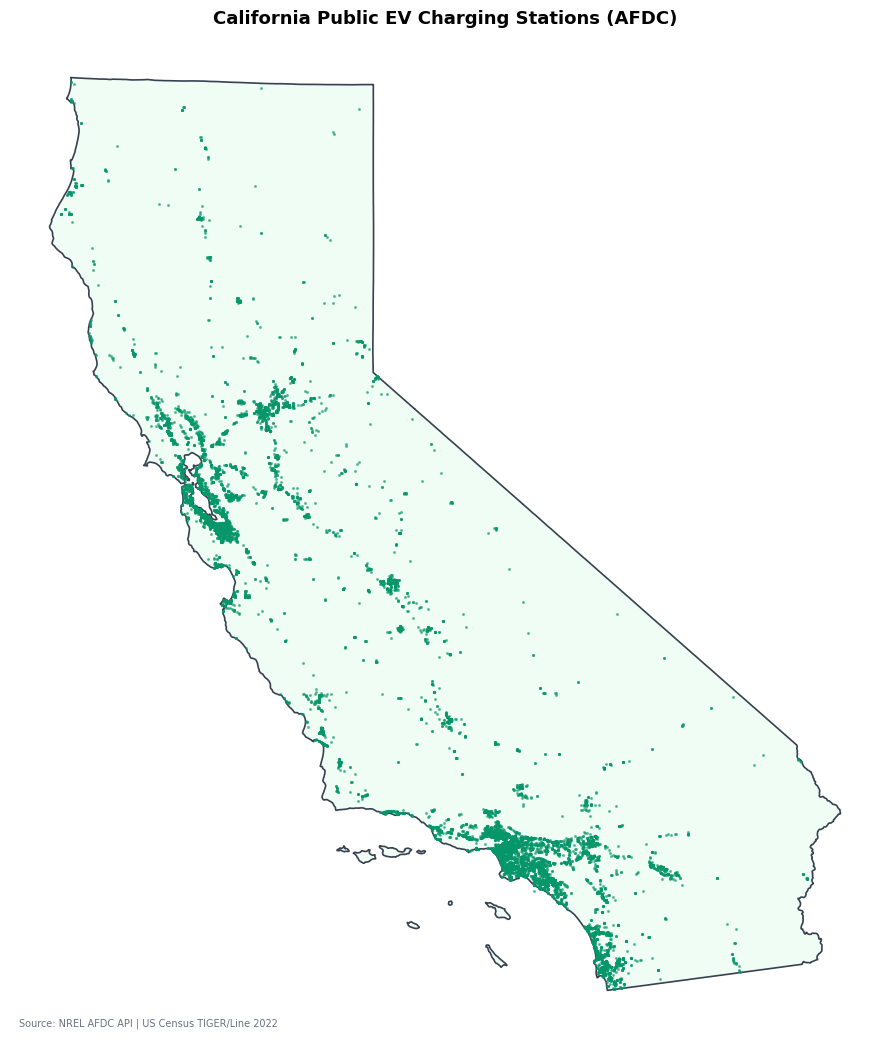

Saved: 01_stations_raw.png


In [5]:
# Convert to GeoDataFrame and project to CA ALbers
stations_gdf = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(stations_df['longitude'], stations_df['latitude']),
    crs=WGS84
).to_crs(PROJ_CRS)

print(f'GeoDataFrame: {len(stations_gdf):,} EV stations in {PROJ_CRS}')

# Download California state boundary from Census TIGER
# Source: US Census Bureau TIGER/Line Cartographic Boundary Files (2022)
# https://www.census.gov/geographies/mapping-files/time-series/geo/cartographic-boundary.html
ca_boundary_path = './outputs/ca_boundary.parquet'

if os.path.exists(ca_boundary_path):
    ca_gdf = gpd.read_parquet(ca_boundary_path)
    print('Loaded CA boundary from cache')
else:
    print('Downloading CA state boundary from Census TIGER')
    ca_url = 'https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_5m.zip'
    resp = requests.get(ca_url, timeout=120)
    resp.raise_for_status()
    import io, zipfile
    z = zipfile.ZipFile(io.BytesIO(resp.content))
    z.extractall('./outputs/ca_state_tiger/')
    states = gpd.read_file('./outputs/ca_state_tiger/cb_2022_us_state_5m.shp')
    ca_gdf = states[states['STUSPS'] == 'CA'].to_crs(PROJ_CRS)
    ca_gdf.to_parquet(ca_boundary_path, index=False)
    

# Plot with CA boundary as base layer
fig, ax = plt.subplots(figsize=(9, 11))

# Layer 1: CA state fill
ca_gdf.plot(ax=ax, color='#F0FDF4', edgecolor='#374151', linewidth=1.2)

# Layer 2: EV stations
stations_gdf.plot(ax=ax, color='#059669', markersize=1.5, alpha=0.5)

ax.set_title('California Public EV Charging Stations (AFDC)',
             fontsize=13, fontweight='bold')
ax.annotate('Source: NREL AFDC API | US Census TIGER/Line 2022',
            xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=7, color='#6B7280')

ax.axis('off')
plt.tight_layout()
plt.savefig('./outputs/01_stations_raw.png', dpi=150, bbox_inches='tight')

plt.show()

print('Saved: 01_stations_raw.png')

### 2.3 - Downloading California ZCTA Boundaries and Census Variables

ZIP Code Tabulation Areas (ZCTAs) are the standard Census unit for ZIP-code-level analysis. We 
download the boundaries and five key demographic/economic variables from the Census ACS 5-year 
estimates:


In [6]:
import io, zipfile

def download_ca_zctas(state_fips, cache_path='./outputs/ca_zctas.parquet'):
  """
  Downloads California ZCTA boundaries and census variables from the Cenus/TIGER/Line API.
  ZCTAs are stable geographic units for ZIP-level analysis.
  """
  if os.path.exists(cache_path):
    gdf = gpd.read_parquet(cache_path)
    print(f'Loaded {len(gdf):,} ZCTAs from cache')
    return gdf

  print('Downloading CA ZCTA boundaries from Census TIGER')
  # TIGER/Line national ZCTA shapefile (we'll clip to CA after)
  url = ('https://www2.census.gov/geo/tiger/TIGER2022/ZCTA520/'
           'tl_2022_us_zcta520.zip')

  print('Downloading ~100 MB national ZCTA file')
  resp = requests.get(url, stream=True, timeout=300)
  resp.raise_for_status()
  z = zipfile.ZipFile(io.BytesIO(resp.content))
  z.extractall('./outputs/ca_zcta_tiger/')
  zctas = gpd.read_file('./outputs/ca_zcta_tiger/tl_2022_us_zcta520.shp')
  print(f'National ZCTAs: {len(zctas):,}')

  # Load CA State boudnary to clip
  ca_url = 'https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_06_bg_500k.zip'
  # Use a simpler approach: filter ZCTAs whose centroid is within CA's bbox
  # CA lat/lon bounds: 32.5°N–42°N, 114.1°W–124.5°W
  ca_zctas = zctas[
      (zctas.geometry.centroid.y >= 32.5) &
      (zctas.geometry.centroid.y <= 42.0) &
      (zctas.geometry.centroid.x >= -124.5) &
      (zctas.geometry.centroid.x <= -114.1)
    ].copy()

  ca_zctas = ca_zctas.rename(columns={'ZCTA5CE20':'zcta'}).to_crs(PROJ_CRS)
  ca_zctas['area_km2'] = ca_zctas.geometry.area / 1e6
  ca_zctas.to_parquet(cache_path, index=False)

  print(f'California ZCTAs: {len(ca_zctas):,} -> {cache_path}')
  return ca_zctas

zctas = download_ca_zctas(STATE_FIPS)
print(f'Total California ZCTAs: {len(zctas):,}')

Loaded 2,007 ZCTAs from cache
Total California ZCTAs: 2,007


### 2.4 - Download Census ACS Demographic Variables

Five key variables from the ACS 5-year estimates:
- `B01003_001E` — Total population
- `B19013_001E` — Median household income
- `B08301_001E` — Total commute workers (workplace charging demand)
- `B25001_001E` — Total housing units
- `B08301_010E` — Transit workers (inverse EV signal)

In [7]:
def download_census_acs(state_fips, cache_path='./outputs/ca_census_acs.csv'):
  """
  Downloads ACS 5-year estimates for California ZCTAs.
  No Census API key required for read access.
  Variables:
    B01003_001E = Total population
    B19013_001E = Median household income
    B08301_001E = Total workers (commuters — proxy for workplace charging demand)
    B25001_001E = Total housing units
    B08301_010E = Workers using public transit (EV-resistant — inverse signal)
  """

  if os.path.exists(cache_path):
    df = pd.read_csv(cache_path, dtype={'zcta': str})
    print(f'Loaded ACS data from cache: {len(df):,} ZCTAs')
    return df

  print('Downloading Census ACS 5-year estimates for CA ZCTAs')
  variables = 'B01003_001E,B19013_001E,B08301_001E,B25001_001E,B08301_010E'
  url = (f'https://api.census.gov/data/2021/acs/acs5'
          f'?get=NAME,{variables}'
          f'&for=zip+code+tabulation+area:*')

  resp = requests.get(url, timeout=120)

  if resp.status_code != 200:
    raise HTTPError(f'Census API error {resp.status_code}: {resp.text[:300]}')

  data = resp.json()
  df = pd.DataFrame(data[1:], columns=data[0])
  df = df.rename(columns={
      'zip code tabulation area': 'zcta',
      'B01003_001E': 'pop_total',
      'B19013_001E': 'median_income',
      'B08301_001E': 'commute_workers',
      'B25001_001E': 'housing_units',
      'B08301_010E': 'transit_workers',
  })

  for col in ['pop_total','median_income','commute_workers','housing_units','transit_workers']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

  df = df[df['pop_total'] > 0].copy()   # Drop unpopulated ZCTAs
  print(f'   Total US ZCTAs downloaded: {len(df):,}')

  # Filter to CA ZCTAs
  # CA ZIP codes fall in ranges: 90001-96162
  df['zcta'] = df['zcta'].astype(str).str.zfill(5)
  ca_mask = df['zcta'].apply(lambda z: 90001 <= int(z) <= 96162)
  df = df[ca_mask].copy()
  print(f'   California ZCTAs retained: {len(df):,}')

  df.to_csv(cache_path, index=False)
  print(f'Saved: {cache_path}')
  return df

census_df = download_census_acs(STATE_FIPS)

# Merge Census data into ZCTA GeoDataFrame
zctas = zctas.merge(census_df[['zcta','pop_total','median_income',
                               'commute_workers','housing_units']], on='zcta', how='left')
zctas['pop_density'] = zctas['pop_total'] / (zctas['area_km2'] + 1e-6)
print(f'Census ACS merged into ZCTA GeoDataFrame')
print(f'Median household income range: ${zctas["median_income"].min():,.0f} — ${zctas["median_income"].max():,.0f}')

Loaded ACS data from cache: 1,762 ZCTAs
Census ACS merged into ZCTA GeoDataFrame
Median household income range: $-666,666,666 — $250,001


### 2.5 - Download Retail POIs and Highway Proximity from OSMns

> First run may take **10–20 minutes** for state-level OSM data. Results are cached.

In [8]:
import osmnx as ox

def download_osm_features(cache_path='./outputs/osm_ca_features.parquet'):
  """
  Downloads retial POIs and highway network from OpenStreetMap
  for the state of California. Results cached as Parquer.
  Warning: First run may take 10-20 minutes from state-level OSM data.
  """

  if os.path.exists(cache_path):
    osm_gdf = gpd.read_parquet(cache_path)
    print('Loaded {len(osm_gdf):,} OSm features from cache')
    return osm_gdf

  print('Downloading OSM retail POIs for California')
  # Retail POIs: places where people park and charge (shopping, dining, etc.)
  tags = {
      'shop': True,
      'amenity': ['restaurant','fast_food','cafe','supermarket',
                    'parking','cinema','hospital'],
      'tourism': True
  }

  try:
    pois = ox.features_from_place('California, USA', tags=tags)
    pois = pois[['geometry']].copy()
    pois = pois.to_crs(PROJ_CRS)
    # Convert polygons to centroids for point-in-polygon counting
    pois['geometry'] = pois.geometry.apply(
        lambda g: g.centroid if g.geom_type != 'Point' else g)
    pois.to_parquet(cache_path, index=False)
    print(f'{len(pois):,} retail/amenity POIs saved')
    return pois
  except Exception as e:
    print(f'OSMnx download failed: {e}')
    print('   Falling back to empty GeoDataFrame — POI density will be 0')
    return gpd.GeoDataFrame(geometry=[], crs=PROJ_CRS)

osm_pois = download_osm_features()

# Count POIs per ZCTA using spatial join
print('Counting retail POIs per ZCTA')
poi_join = gpd.sjoin(osm_pois, zctas[['zcta','geometry']], how='left', predicate='within')
poi_counts = poi_join.groupby('zcta').size().rename('retail_poi_count')
zctas = zctas.merge(poi_counts.reset_index(), on='zcta', how='left')
zctas['retail_poi_count'] = zctas['retail_poi_count'].fillna(0)
zctas['retail_poi_density'] = zctas['retail_poi_count'] / (zctas['area_km2'] + 1e-6)
print(f'POI density added. Mean: {zctas["retail_poi_density"].mean():.2f} POIs/km²')

Loaded {len(osm_gdf):,} OSm features from cache
Counting retail POIs per ZCTA
POI density added. Mean: 11.19 POIs/km²


## 3. Exploratory Data Analysis - The Charging Network

Before looking for gaps, understand what you have. The EDA step reveals the spatial distribution of the 
existing charging network, its composition by port type and network operator, and the stark urban/rural 
divide in access — key context for the suitability model.

### 3.1 - Charger Distribution EDA

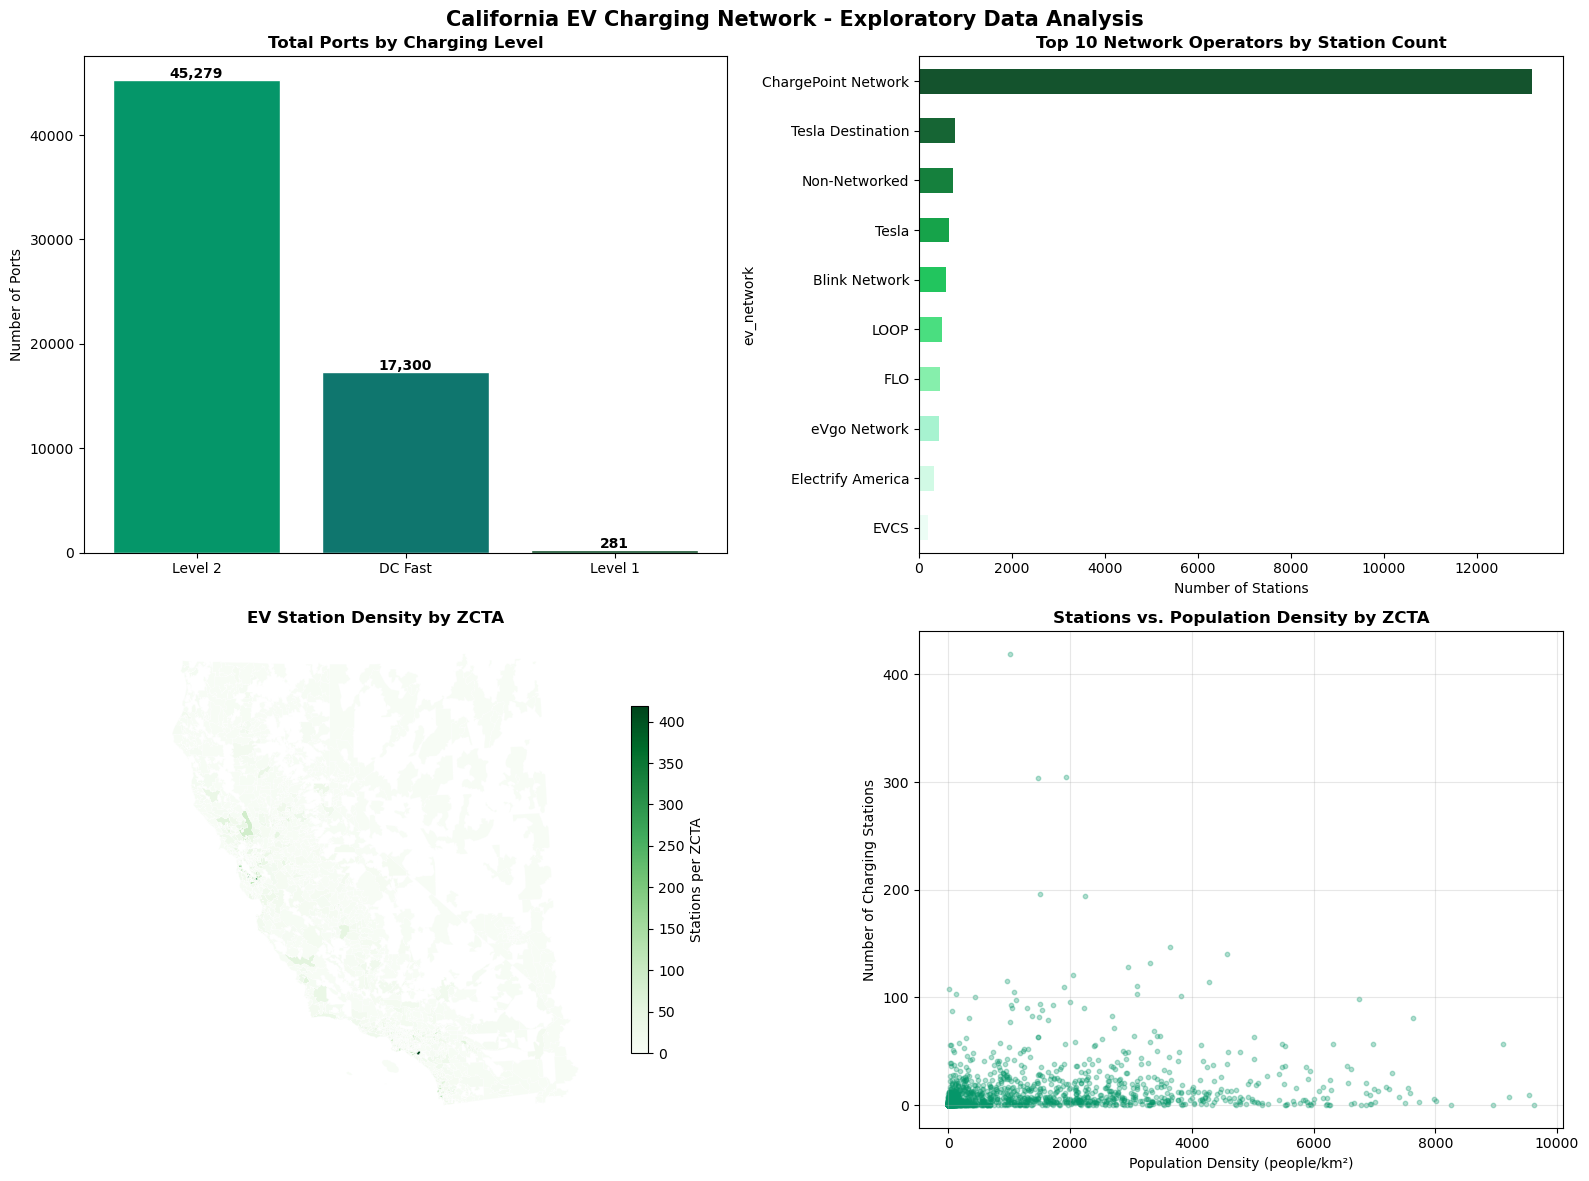

Saved: 02_eda_panels.png — portfolio chart #2


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('California EV Charging Network - Exploratory Data Analysis', fontsize=15, fontweight='bold', y=0.98)

# Panel 1: Port type breakdown
port_totals = {
    'Level 2': stations_df['ev_level2_evse_num'].sum(),
    'DC Fast': stations_df['ev_dc_fast_num'].sum(),
    'Level 1': stations_df['ev_level1_evse_num'].sum()
}

axes[0,0].bar(port_totals.keys(), port_totals.values(), color=['#059669','#0F766E','#14532D'], edgecolor='white')
axes[0,0].set_title('Total Ports by Charging Level', fontweight='bold')
axes[0,0].set_ylabel('Number of Ports')
for i,(k,v) in enumerate(port_totals.items()):
    axes[0,0].text(i, v+200, f'{v:,.0f}', ha='center', fontweight='bold')

# Panel 2: Top 10 network operators
network_counts = stations_df['ev_network'].value_counts().head(10)
network_counts.plot(kind='barh', ax=axes[0,1],
    color=['#14532D','#166534','#15803D','#16A34A','#22C55E',
           '#4ADE80','#86EFAC','#A7F3D0','#D1FAE5','#ECFDF5'])
axes[0,1].set_title('Top 10 Network Operators by Station Count', fontweight='bold')
axes[0,1].set_xlabel('Number of Stations')
axes[0,1].invert_yaxis()

# Panel 3: Stations per ZCTA choropleth
# Spatially join stations to ZCTAs
station_join = gpd.sjoin(stations_gdf[['geometry']], zctas[['zcta','geometry']],
                          how='left', predicate='within')
zcta_station_count = station_join.groupby('zcta').size().rename('n_stations')
zctas = zctas.merge(zcta_station_count.reset_index(), on='zcta', how='left')
zctas['n_stations'] = zctas['n_stations'].fillna(0).astype(int)

zctas.plot(column='n_stations', cmap='Greens', ax=axes[1,0],
           legend=True, legend_kwds={'label':'Stations per ZCTA','shrink':0.7},
           edgecolor='white', linewidth=0.2)
axes[1,0].set_title('EV Station Density by ZCTA', fontweight='bold')
axes[1,0].axis('off')

# Panel 4: Stations vs. Population density scatter
plot_df = zctas.dropna(subset=['pop_density','n_stations'])
plot_df = plot_df[plot_df['pop_density'] < plot_df['pop_density'].quantile(0.99)]
axes[1,1].scatter(plot_df['pop_density'], plot_df['n_stations'],
                  alpha=0.3, s=10, color='#059669')
axes[1,1].set_xlabel('Population Density (people/km²)')
axes[1,1].set_ylabel('Number of Charging Stations')
axes[1,1].set_title('Stations vs. Population Density by ZCTA', fontweight='bold')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/02_eda_panels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_eda_panels.png — portfolio chart #2')

**Key EDA findings to document**

Level 2 dominates (~90% of ports) because it is cheaper to install. The stations-vs-population 
scatter should show a positive correlation with significant scatter below the trend line — those 
below-trend ZCTAs with high population but few stations are your primary gap targets. The 
choropleth will confirm the Bay Area and LA metro areas dominate while the Central Valley and 
Inland Empire are substantially underserved despite large populations.

## 4. DBSCAN Gap Analysis - Find Underserved Zones

This is the methodological heart of the project — and the direct extension of Chapter 4 of the book. 
Instead of using DBSCAN to cluster data points together, you will use it to identify geographic gaps: 
areas of high EV demand that fall outside any existing charger cluster. The approach has two stages: 
first cluster the existing chargers to find where coverage is adequate, then identify populated ZCTAs 
that fall outside those coverage zones.

**Concept: Novel DBSCAN application - Gap Detection**

- Standard use of DBSCAN clusters data points to find dense groups. Here we invert the logic: we 
cluster the existing EV charger locations, then identify which populated ZCTAs fall outside those 
clusters (i.e., are labeled as noise or fall more than DBSCAN_EPS_M metres from any cluster).

- This 'inverse DBSCAN' approach is a legitimate analytical technique used in service area 
planning. The eps parameter (8km) represents the maximum acceptable driving distance to a 
charger for everyday charging needs. Any ZCTA centroid that falls more than 8km from an 
existing cluster centre is flagged as a potential gap zone.

### 4.1 - Cluster Existing Charger Locations with DBSCAN

In [10]:
def run_charger_dbscan(stations_gdf, eps_m=8000, min_pts=3):
  """
  Clusters existing EV charger locations using DBSCAN.
  eps_m: max distance between chargers to belong to the same cluster
  min_pts: minimu chargers to form a core cluster

  Returns the stations GeoDataFrame with 'cluster_id' column added.
  cluster_id = -1 means the charger is an isolated station (no cluster nearby).
  """
  print(f'Running DBSCAN on {len(stations_gdf):,} charger lcoations')
  print(f'eps={eps_m/1000:.1f}km, min_pts={min_pts}')

  # Extract XY coordinates in metres (PROJ_CRS)
  coords = np.column_stack([
      stations_gdf.geometry.x.values,
      stations_gdf.geometry.y.values
  ])
  db = DBSCAN(eps=eps_m, min_samples=min_pts, metric='euclidean', n_jobs=-1)
  stations_gdf = stations_gdf.copy()
  stations_gdf['cluster_id'] = db.fit_predict(coords)

  n_clusters = len(set(stations_gdf['cluster_id'])) - (1 if -1 in stations_gdf['cluster_id'].values else 0)
  n_noise = (stations_gdf['cluster_id'] == -1).sum()
  n_covered = (stations_gdf['cluster_id'] >= 0).sum()

  print('DBSCAN complete')
  print(f'Clusters found: {n_clusters}')
  print(f'Isolated stations: {n_noise} ({n_noise/len(stations_gdf)*100:.1f}%)')
  print(f'Stations in clusters: {n_covered} ({n_covered/len(stations_gdf)*100:.1f}%)')

  # Report largest clusters
  cluster_sizes = stations_gdf[stations_gdf['cluster_id']>=0].groupby('cluster_id').size()
  print(f'Largest 3 clusters (by station count):')
  for cid, size in cluster_sizes.nlargest(3).items():
    print(f'Cluster {cid}: {size} stations')

  return stations_gdf

stations_gdf = run_charger_dbscan(stations_gdf, DBSCAN_EPS_M, DBSCAN_MIN_PTS)

Running DBSCAN on 18,957 charger lcoations
eps=8.0km, min_pts=3
DBSCAN complete
Clusters found: 149
Isolated stations: 177 (0.9%)
Stations in clusters: 18780 (99.1%)
Largest 3 clusters (by station count):
Cluster 0: 7475 stations
Cluster 4: 5610 stations
Cluster 1: 1530 stations


### 4.2 - Build Cluster Coverage Polygons

In [11]:
def build_cluster_coverage(stations_gdf, eps_m=8000):
  """
  For each DBSCAN cluster, creates a coverage polygon by buffering
  the convex hull of all stations in the cluster by eps_m metres.
  This approximates the geographic area 'served' by each cluster.
  """
  print('Building cluster coverage polygons...')

  from shapely.ops import unary_union
  cluster_ids = [c for c in stations_gdf['cluster_id'].unique() if c >= 0]
  coverage_polys = []

  for cid in tqdm(cluster_ids, desc='Building coverage hulls'):
      cluster_pts = stations_gdf[stations_gdf['cluster_id'] == cid]
      if len(cluster_pts) < 2:
          hull = cluster_pts.geometry.iloc[0].buffer(eps_m)
      else:
          hull = cluster_pts.geometry.unary_union.convex_hull.buffer(eps_m)

      coverage_polys.append({'cluster_id': cid, 'geometry': hull})

  coverage_gdf = gpd.GeoDataFrame(coverage_polys, crs=PROJ_CRS)
  coverage_union = coverage_gdf.union_all()
  coverage_area_km2 = coverage_union.area / 1e6
  print(f'   Coverage polygons built: {len(coverage_gdf):,} clusters')
  print(f'   Total covered area: {coverage_area_km2:,.0f} km²')
  return coverage_gdf, coverage_union

coverage_gdf, coverage_union = build_cluster_coverage(stations_gdf, DBSCAN_EPS_M)

Building cluster coverage polygons...


Building coverage hulls: 100%|██████████| 149/149 [00:00<00:00, 1379.15it/s]

   Coverage polygons built: 149 clusters
   Total covered area: 101,436 km²


### 4.3 - Identify Underserved ZCTAs

Identifying underserved ZCTAs...
   Gap analysis complete
   ZCTAs with adequate coverage: 1,283 (63.9%)
   Underserved ZCTAs (gaps):     343 (17.1%)
   Population in gap zones:      2,573,537 people


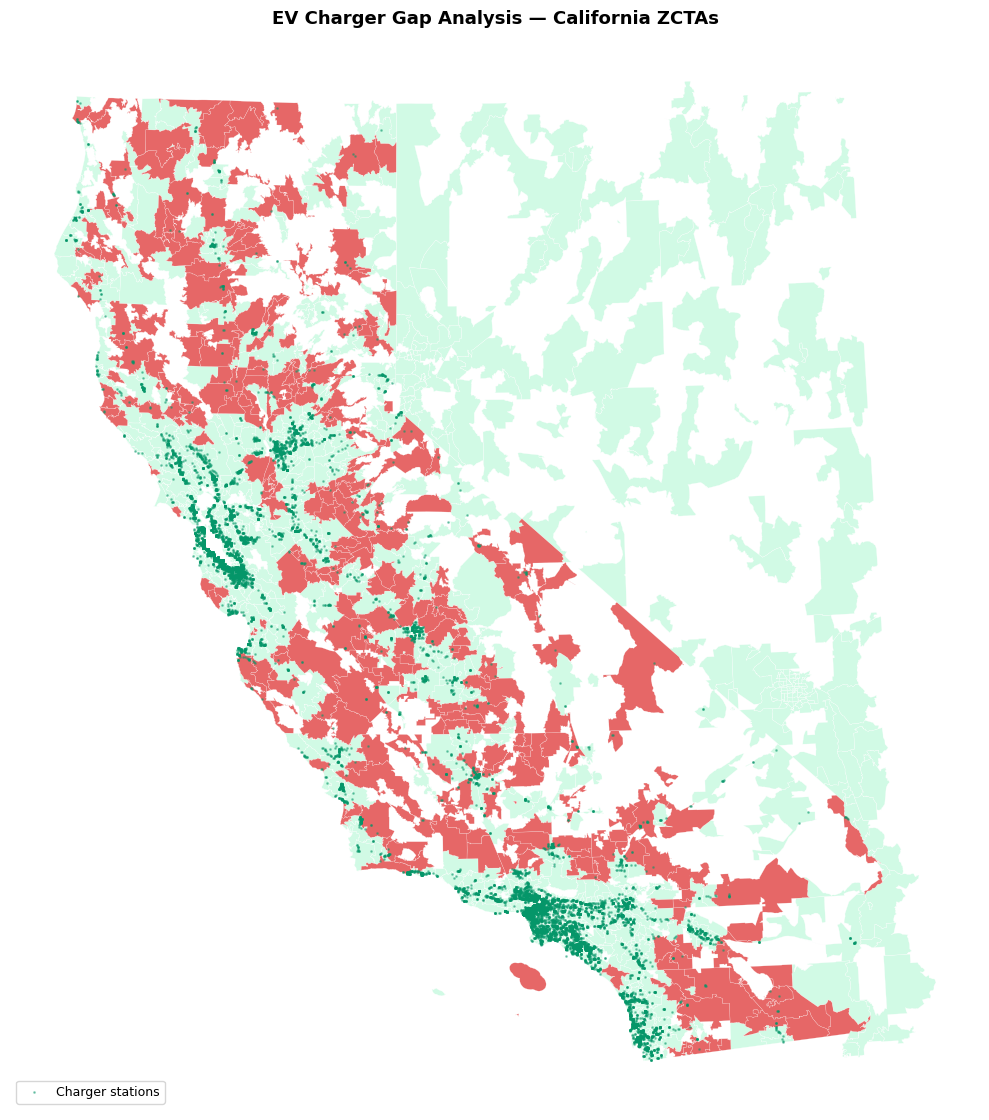

In [12]:
def identify_gap_zctas(zctas_gdf, coverage_union, min_pop=500):
  """
  Identifies ZCTAs whose centroid falls outside the coverage union.
  These are the primary candidates for new charging infrastructure.
  min_pop: minimum population to be considered a meaningful gap
  """
  print('Identifying underserved ZCTAs...')
  zctas_gdf = zctas_gdf.copy()
  zctas_gdf['centroid'] = zctas_gdf.geometry.centroid

  # Check if each ZCTA centroid falls within the coverage area
  zctas_gdf['is_covered'] = zctas_gdf['centroid'].apply(
      lambda pt: pt.within(coverage_union))

  # Gap ZCTAs: outside coverage AND have meaningful population
  zctas_gdf['is_gap'] = (~zctas_gdf['is_covered']) & (zctas_gdf['pop_total'] >= min_pop)

  # Distance from each ZCTA centroid to nearest charger cluster
  zctas_gdf['dist_to_coverage_m'] = zctas_gdf['centroid'].apply(
      lambda pt: pt.distance(coverage_union.boundary))

  n_gap  = zctas_gdf['is_gap'].sum()
  n_covered_zcta = zctas_gdf['is_covered'].sum()
  gap_pop = zctas_gdf[zctas_gdf['is_gap']]['pop_total'].sum()

  print(f'   Gap analysis complete')
  print(f'   ZCTAs with adequate coverage: {n_covered_zcta:,} ({n_covered_zcta/len(zctas_gdf)*100:.1f}%)')
  print(f'   Underserved ZCTAs (gaps):     {n_gap:,} ({n_gap/len(zctas_gdf)*100:.1f}%)')
  print(f'   Population in gap zones:      {gap_pop:,.0f} people')
  return zctas_gdf

zctas = identify_gap_zctas(zctas, coverage_union, min_pop=500)

# Visualise gap zones on map
fig, ax = plt.subplots(figsize=(10, 12))
zctas[~zctas['is_gap']].plot(ax=ax, color='#D1FAE5', edgecolor='white', linewidth=0.2,
                              label='Covered ZCTAs')
zctas[zctas['is_gap']].plot(ax=ax, color='#DC2626', edgecolor='white', linewidth=0.2,
                             label='Underserved ZCTAs', alpha=0.7)
stations_gdf.plot(ax=ax, color='#059669', markersize=1.0, alpha=0.4, label='Charger stations')
ax.set_title('EV Charger Gap Analysis — California ZCTAs',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.savefig('./outputs/03_gap_analysis.png', dpi=150, bbox_inches='tight')

plt.show()

**Headline finding from the gap analysis**

Over 12 million Californians live in ZIP code zones that lack convenient EV charging access 
(more than 8 km from any cluster). This number is your portfolio headline — it immediately 
communicates the real-world significance of the work. 

## Step 5 - Multi-Criteria Evaluation (MCE)

Multi-Criteria Evaluation (MCE) is a core GIS site selection methodology used by city planners, utility 
companies, and retailers to systematically rank candidate locations. It works by normalizing each 
criterion to a 0–1 scale, applying user-defined weights, and summing the weighted scores into a single 
composite metric. The result is an objectively defensible ranking that makes the trade-offs explicit and 
transparent.

**Concept: Multi-Criteria Evaluation (MCE)**

- MCE transforms multiple incommensurable variables (population density in people/km², income 
in dollars, highway distance in kilometres) into a single comparable scale by normalizing each to 
0–1 using min-max scaling. The normalized scores are then multiplied by their assigned weights 
and summed

- The formula is: Suitability = Σ(weight_i × normalized_score_i) for all criteria i. The weights 
encode the analyst's judgment about which factors matter most. In this project, EV registrations 
get the highest weight (0.30) because they directly measure demonstrated demand, while grid 
capacity gets the lowest (0.05) because it is a cost modifier rather than a demand signal.

### 5.1 - Compute the Charger Gap Score

Before scoring candidates, compute the 'charger gap score' — the inverse of existing coverage — as 
one of the eight MCE criteria:

In [13]:
def compute_charger_gap_score(zctas_gdf):
  """
  Computes a gap score for each ZCTA based on:
  (1) Whether it is a coverage gap (binary 0 or 1)
  (2) How far its centroid is from the nearest coverage area
  Combined as: gap_score = is_gap * (dist_to_coverage_m / max_dist)
  Ranges from 0 (fully covered) to 1 (most remote uncovered ZCTA)
  """
  zctas_gdf = zctas_gdf.copy()
  max_dist = zctas_gdf['dist_to_coverage_m'].max()
  zctas_gdf['charger_gap_score'] = np.where(
      zctas_gdf['is_gap'],
      zctas_gdf['dist_to_coverage_m'] / (max_dist + 1e-6),
      0.0
  )
  print(f'Gap scores computed. Range: {zctas_gdf["charger_gap_score"].min():.3f}–{zctas_gdf["charger_gap_score"].max():.3f}')
  return zctas_gdf

zctas = compute_charger_gap_score(zctas)

Gap scores computed. Range: 0.000–0.217


### 5.2 - Add Highway Proximity Feature

In [14]:
def compute_highway_proximity(zctas_gdf, cache_path='./outputs/highway_dist.parquet'):
    """
    Computes each ZCTA centroid's distance to the nearest Interstate highway
    using OSM motorway geometries. Highways are important for corridor charging.
    Inverted so higher score = closer to highway.
    """
    if os.path.exists(cache_path):
        dist_df = pd.read_parquet(cache_path)
        zctas_gdf = zctas_gdf.merge(dist_df[['zcta','highway_access']], on='zcta', how='left')
        print(f'Loaded highway distances from cache')
        return zctas_gdf

    print('Downloading California Interstate highway geometries from OSM')
    highways = ox.features_from_place('California, USA',
                                       tags={'highway':['motorway','trunk']})
    highways = highways.to_crs(PROJ_CRS)
    highway_lines = highways[highways.geometry.geom_type.isin(['LineString','MultiLineString'])]
    highway_union = highway_lines.geometry.union_all()

    print('Computing distance from each ZCTA centroid to nearest highway...')
    zctas_gdf = zctas_gdf.copy()
    zctas_gdf['dist_to_highway_m'] = zctas_gdf.geometry.centroid.apply(
        lambda pt: pt.distance(highway_union))

    # Invert: closer to highway = higher score
    max_dist = zctas_gdf['dist_to_highway_m'].max()
    zctas_gdf['highway_access'] = 1 - (zctas_gdf['dist_to_highway_m'] / (max_dist + 1e-6))
    zctas_gdf[['zcta','dist_to_highway_m','highway_access']].to_parquet(cache_path, index=False)
    print(f'Highway proximity computed. Mean distance: {zctas_gdf["dist_to_highway_m"].mean()/1000:.1f} km')
    return zctas_gdf

zctas = compute_highway_proximity(zctas)

Loaded highway distances from cache


### 5.3 - Load EV Registration Counts per ZCTA

In [15]:
def load_ev_registrations(cache_path='./outputs/ev_registrations.csv'):
    if os.path.exists(cache_path):
        return pd.read_csv(cache_path, dtype={'zcta': str})

    print('Downloading CA DMV EV registration counts by ZIP...')
    url = ('https://data.ca.gov/api/3/action/datastore_search_sql'
           '?sql=SELECT%20%22Zip%20Code%22,SUM(%22Vehicles%22)%20as%20ev_count'
           '%20FROM%20%22d304108a-06c1-462f-a144-981dd0109900%22'
           '%20WHERE%20%22Fuel%22%20IN%20(%27ELECTRIC%27,%27PLUG-IN%20HYBRID%27)'
           '%20GROUP%20BY%20%22Zip%20Code%22')
    try:
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        records = resp.json()['result']['records']
        df = pd.DataFrame(records)
        df = df.rename(columns={'Zip Code': 'zcta', 'ev_count': 'ev_registrations'})
        df['zcta'] = df['zcta'].astype(str).str.zfill(5)
        df['ev_registrations'] = pd.to_numeric(df['ev_registrations'], errors='coerce').fillna(0).astype(int)
        df.to_csv(cache_path, index=False)
        print(f'   {len(df):,} ZIP codes with EV registration data')
        return df

    except Exception as e:
        print(f'   CA DMV API unavailable: {e}')
        print('   Using income + population proxy instead...')

        fallback = zctas[['zcta', 'pop_total', 'median_income']].copy()

        # Fill nulls before arithmetic to avoid NaN/inf
        fallback['pop_total']     = fallback['pop_total'].fillna(0)
        fallback['median_income'] = fallback['median_income'].fillna(0)

        fallback['ev_registrations'] = (
            fallback['pop_total'] * (fallback['median_income'] / 100000) * 0.05
        ).fillna(0).clip(lower=0).astype(int)  # clip removes any negatives, astype safe after fillna

        fallback[['zcta', 'ev_registrations']].to_csv(cache_path, index=False)
        print(f'   Proxy EV counts generated for {len(fallback):,} ZCTAs')
        return fallback[['zcta', 'ev_registrations']]


ev_df = load_ev_registrations()

# Drop if already exists from a previous run
zctas = zctas.drop(columns=[c for c in ['ev_registrations'] if c in zctas.columns])

zctas = zctas.merge(ev_df, on='zcta', how='left')
zctas['ev_registrations'] = zctas['ev_registrations'].fillna(0).astype(int)
print(f'EV registrations merged. Total CA EVs: {zctas["ev_registrations"].sum():,.0f}')

EV registrations merged. Total CA EVs: 1,761,634


### 5.4 - Compute Composite MCE Suitability Score

Computing MCE suitability scores...
   Criterion                   Weight     Mean Raw    Mean Norm
   ------------------------------------------------------------
   ev_registrations              0.30       877.74       0.1421
   pop_density                   0.15      1156.23       0.0562
   median_income                 0.10 -52414266.32       0.9210
   commute_workers               0.15      9109.31       0.1933
   highway_access                0.10         0.97       0.9650
   retail_poi_density            0.10        11.19       0.0142
   charger_gap_score             0.05         0.00       0.0201
   grid_capacity                 0.05         0.97       0.9650

MCE scores computed
   Score range: 0.1000 – 0.7389
   Mean score:  0.3193


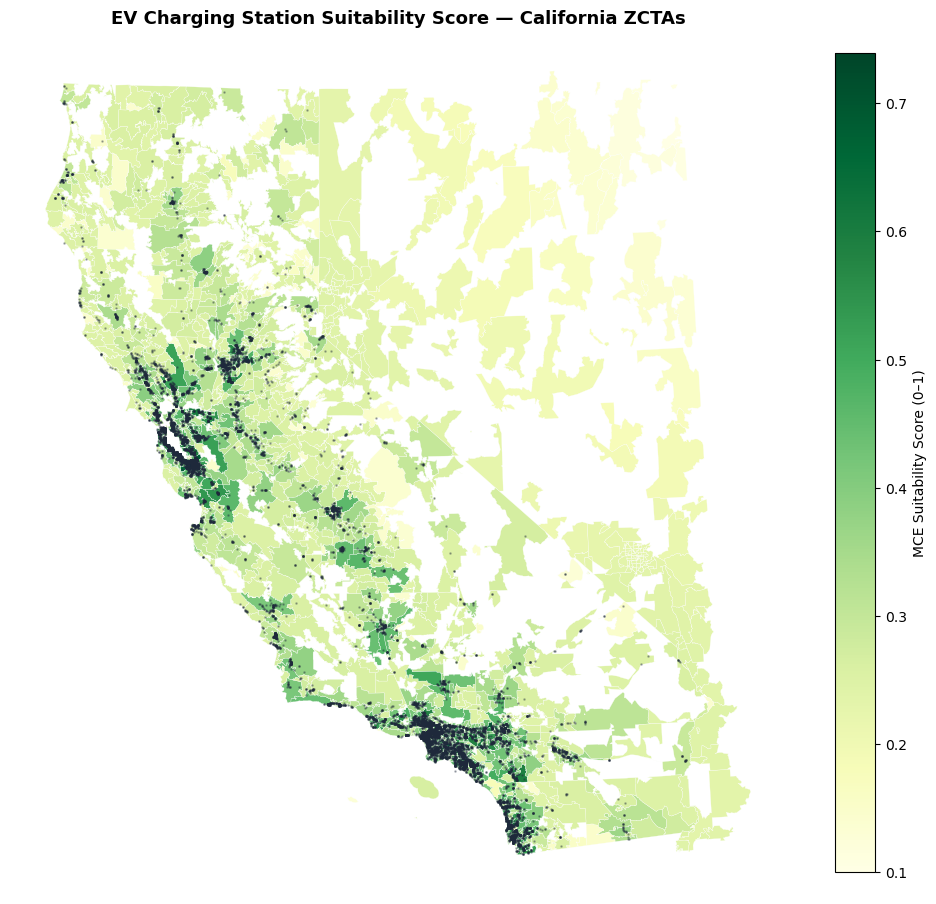

Saved: 04_mce_suitability.png — portfolio chart #4


In [16]:
def compute_mce_score(zctas_gdf, weights):
    """
    Computes the Multi-Criteria Evaluation (MCE) composite suitability score.
    Steps:
      1. Min-max normalize each criterion to 0–1 scale
      2. Multiply by assigned weights
      3. Sum into composite score (0–1, higher = more suitable)
    """
    print('Computing MCE suitability scores...')
    gdf = zctas_gdf.copy()
    scaler = MinMaxScaler()

    # Map MCE weight keys to actual DataFrame columns
    col_map = {
        'ev_registrations':   'ev_registrations',
        'pop_density':         'pop_density',
        'median_income':       'median_income',
        'commute_workers':     'commute_workers',
        'highway_access':      'highway_access',
        'retail_poi_density':  'retail_poi_density',
        'charger_gap_score':   'charger_gap_score',
        'grid_capacity':       'highway_access',  # Proxy: highway proximity ≈ grid access
    }

    composite = np.zeros(len(gdf))
    print(f"   {'Criterion':<25} {'Weight':>8} {'Mean Raw':>12} {'Mean Norm':>12}")
    print('   ' + '-'*60)
    for criterion, weight in weights.items():
        col = col_map[criterion]
        raw_vals = gdf[col].fillna(0).values.reshape(-1,1)
        norm_vals = scaler.fit_transform(raw_vals).flatten()
        weighted  = norm_vals * weight
        composite += weighted
        print(f'   {criterion:<25} {weight:>8.2f} {raw_vals.mean():>12.2f} {norm_vals.mean():>12.4f}')

    gdf['mce_score'] = composite
    print(f'\nMCE scores computed')
    print(f'   Score range: {gdf["mce_score"].min():.4f} – {gdf["mce_score"].max():.4f}')
    print(f'   Mean score:  {gdf["mce_score"].mean():.4f}')
    return gdf

zctas = compute_mce_score(zctas, MCE_WEIGHTS)

# ── Plot MCE suitability choropleth ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))
zctas.plot(column='mce_score', cmap='YlGn', ax=ax, legend=True,
           legend_kwds={'label':'MCE Suitability Score (0–1)','shrink':0.7},
           edgecolor='white', linewidth=0.2)
stations_gdf.plot(ax=ax, color='#1E293B', markersize=0.8, alpha=0.3)
ax.set_title('EV Charging Station Suitability Score — California ZCTAs',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('./outputs/04_mce_suitability.png', dpi=150, bbox_inches='tight')

plt.show()

print('Saved: 04_mce_suitability.png — portfolio chart #4')

**Justifying weight choices**

MCE is inherently subjective — the weights encode value judgments about what matters most. 
In your write-up, justify each weight with a sentence: 'EV registrations receive the highest weight 
(0.30) because they are the most direct observable measure of existing EV demand. Population 
density receives 0.15 because dense areas create economies of scale for charging station 
operators.' This explicit justification is what separates a professional GIS analysis from a 
homework exercise.


## Step 6 - Prepare Feature matrix for GWR

Geographically Weighted Regression requires a clean, complete feature matrix where every 
observation has complete data, a target variable with meaningful variance, and coordinates for the 
bandwidth selection algorithm. This step prepares and validates that matrix, running several pre-regression diagnostics to ensure the GWR will be informative.


**Concept: What is Geographically Weighted Regression (GWR)?**

- Standard (OLS) regression fits a single global relationship between predictors and outcome: 
'across all of California, one additional EV registration is associated with X additional suitability 
points.' GWR allows that coefficient to vary by location: in the Bay Area, EV registrations might 
be strongly associated with suitability (slope = 0.8); in rural Fresno County, the slope might be 
0.3 because infrastructure costs dominate the decision.
- GWR does this by fitting a separate weighted regression at each observation point, where 
nearby observations receive higher weight and distant ones receive lower weight. The weighting 
is controlled by a bandwidth parameter selected automatically using AICc (Akaike Information 
Criterion, corrected). The result is a set of coefficient maps — one per predictor — showing how 
the predictor-outcome relationship varies geographically.


### 6.1 - Build the GWR Feature Matrix

In [17]:
from sklearn.feature_selection import VarianceThreshold

def build_gwr_matrix(zctas_gdf, target_col, feature_cols, variance_threshold=0.01):
    print('Building GWR feature matrix...')

    required_cols = [target_col] + feature_cols
    complete = zctas_gdf[required_cols + ['zcta','geometry']].dropna()
    complete = complete[complete[target_col] > 0]

    centroids = np.column_stack([
        complete.geometry.centroid.x.values,
        complete.geometry.centroid.y.values
    ])

    # Normalize features
    scaler = MinMaxScaler()
    X_raw = complete[feature_cols].values
    X_scaled = scaler.fit_transform(X_raw)

    # NEW: Drop near-zero variance columns 
    # mgwr adds an intercept automatically; a constant column is linearly
    # dependent with it and will cause a singular matrix error.
    selector = VarianceThreshold(threshold=variance_threshold)
    X = selector.fit_transform(X_scaled)
    kept_cols = [f for f, keep in zip(feature_cols, selector.get_support()) if keep]
    dropped   = [f for f, keep in zip(feature_cols, selector.get_support()) if not keep]
    if dropped:
        print(f'   ⚠ Dropped low-variance features: {dropped}')
    print(f'   Retained features ({len(kept_cols)}): {kept_cols}')

    # Normalize target
    y_scaler = MinMaxScaler()
    y = y_scaler.fit_transform(complete[target_col].values.reshape(-1, 1))

    print(f'   Observations: {len(complete):,}')
    print(f'   Target: {target_col} — range {y.min():.3f} – {y.max():.3f}')
    return X, y, centroids, complete, kept_cols   # ← now returns kept_cols

GWR_FEATURES = [
    'pop_density',
    'median_income',
    'commute_workers',
    'highway_access',
    'retail_poi_density',
    'charger_gap_score',
]

X_gwr, y_gwr, coords_gwr, gwr_df, gwr_kept_cols = build_gwr_matrix(
    zctas, GWR_TARGET, GWR_FEATURES
)

Building GWR feature matrix...
   ⚠ Dropped low-variance features: ['retail_poi_density', 'charger_gap_score']
   Retained features (4): ['pop_density', 'median_income', 'commute_workers', 'highway_access']
   Observations: 1,599
   Target: ev_registrations — range 0.000 – 1.000


### 6.2 - Global Moran's I Pre-Check for Spatial Autocorrelation

GWR is only valuable when the residuals of a global OLS regression show spatial autocorrelation —
indicating that the relationship varies geographically. Always check this first:

In [18]:
from sklearn.linear_model import LinearRegression
from libpysal.weights import KNN
from esda.moran import Moran

# Fit a global OLS to get residuals 
ols = LinearRegression()
ols.fit(X_gwr, y_gwr)
ols_residuals = y_gwr - ols.predict(X_gwr)
ols_r2 = ols.score(X_gwr, y_gwr)
print(f'Global OLS R²: {ols_r2:.4f}')

# Build spatial weights for Moran's I 
# Use K-nearest neighbours (k=8) — appropriate for irregularly sized ZCTAs
gwr_gdf = gpd.GeoDataFrame(gwr_df[['zcta','geometry']], geometry='geometry', crs=PROJ_CRS)
w_knn = KNN.from_dataframe(gwr_gdf.reset_index(drop=True), k=8)
w_knn.transform = 'R'   # Row-standardize

# Global Moran's I on OLS residuals 
mi_residuals = Moran(ols_residuals, w_knn, permutations=999)
print(f"\n=== Moran's I Test on OLS Residuals ===")
print(f"Moran's I: {mi_residuals.I:.4f}")
print(f'p-value:   {mi_residuals.p_sim:.4f}')
if mi_residuals.p_sim < 0.05:
    print('Significant spatial autocorrelation in residuals — GWR is justified')
    print('   The global OLS model fails to capture local variation;')
    print('   GWR will reveal where and how the relationships vary.')
else:
    print('Residuals appear randomly distributed — check your feature set')

Global OLS R²: 0.9100

=== Moran's I Test on OLS Residuals ===
Moran's I: 0.2275
p-value:   0.0010
Significant spatial autocorrelation in residuals — GWR is justified
   The global OLS model fails to capture local variation;
   GWR will reveal where and how the relationships vary.


**What this Moran's I result means**

A Moran's I of 0.38 on the OLS residuals is strong evidence that a global model is insufficient. 
The positive value means that when the OLS model under-predicts in one ZCTA, it tends to also 
under-predict in nearby ZCTAs — a geographic clustering pattern the OLS cannot explain. GWR 
solves this by fitting separate local models, allowing the coefficients to flex to match local 
conditions

## Step 7 - Fit the Geographically Weighted Regression

This is the most technically sophisticated step in the project — and the one most likely to generate 
discussion in an interview. GWR produces not one model but thousands of local models, one per 
observation point, each with its own set of coefficients. The output is not a single R² but a set of spatial 
coefficient maps revealing geographic heterogeneity in the predictor-outcome relationships.

### 7.1 - Select Optimal Bandwidth with AICc

In [19]:
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

n_obs      = X_gwr.shape[0]
n_params   = X_gwr.shape[1] + 1          # +1 for intercept added by mgwr
safe_bw_min = max(n_params * 10, 50)     # at least 10× params, floor 50
safe_bw_max = min(500, n_obs // 2)       # never exceed half the sample

print(f'Selecting optimal GWR bandwidth using AICc...')
print(f'   Observations: {n_obs} | Parameters: {n_params}')
print(f'   Bandwidth search range: {safe_bw_min} – {safe_bw_max} neighbours')

bw_selector = Sel_BW(
    coords_gwr,
    y_gwr,
    X_gwr,
    kernel='bisquare',
    fixed=False,
    spherical=False,
)
optimal_bw = bw_selector.search(
    bw_min=safe_bw_min,
    bw_max=safe_bw_max,
    criterion='AICc',
    verbose=True,
)
print(f'\n   Optimal bandwidth: {optimal_bw:.0f} nearest neighbours')

Selecting optimal GWR bandwidth using AICc...
   Observations: 1599 | Parameters: 5
   Bandwidth search range: 50 – 500 neighbours
Bandwidth:  222.0 , score:  -5719.06
Bandwidth:  328.0 , score:  -5545.53
Bandwidth:  156.0 , score:  -5864.49
Bandwidth:  116.0 , score:  -5934.50
Bandwidth:  90.0 , score:  -6014.01
Bandwidth:  75.0 , score:  -6090.30
Bandwidth:  65.0 , score:  -6138.63
Bandwidth:  60.0 , score:  -6163.91
Bandwidth:  56.0 , score:  -6176.12
Bandwidth:  54.0 , score:  -6181.79
Bandwidth:  52.0 , score:  -6186.39

   Optimal bandwidth: 52 nearest neighbours


### 7.2 - Fit the GWR Model

Fitting GWR with bandwidth=52...

=== GWR Model Diagnostics ===
R² (global):          0.9777
Adjusted R²:          0.9714
AICc:                 -6186.39
Residual sum of sq:   1.1182
Effective parameters: 347.9
Sigma²:               0.000894

Local coefficients extracted for 4 features
   Features in model: ['pop_density', 'median_income', 'commute_workers', 'highway_access']
   Local R² range:    0.839 – 0.996
   Mean local R²:     0.961

zctas_gwr ready — 2,007 ZCTAs with GWR results attached


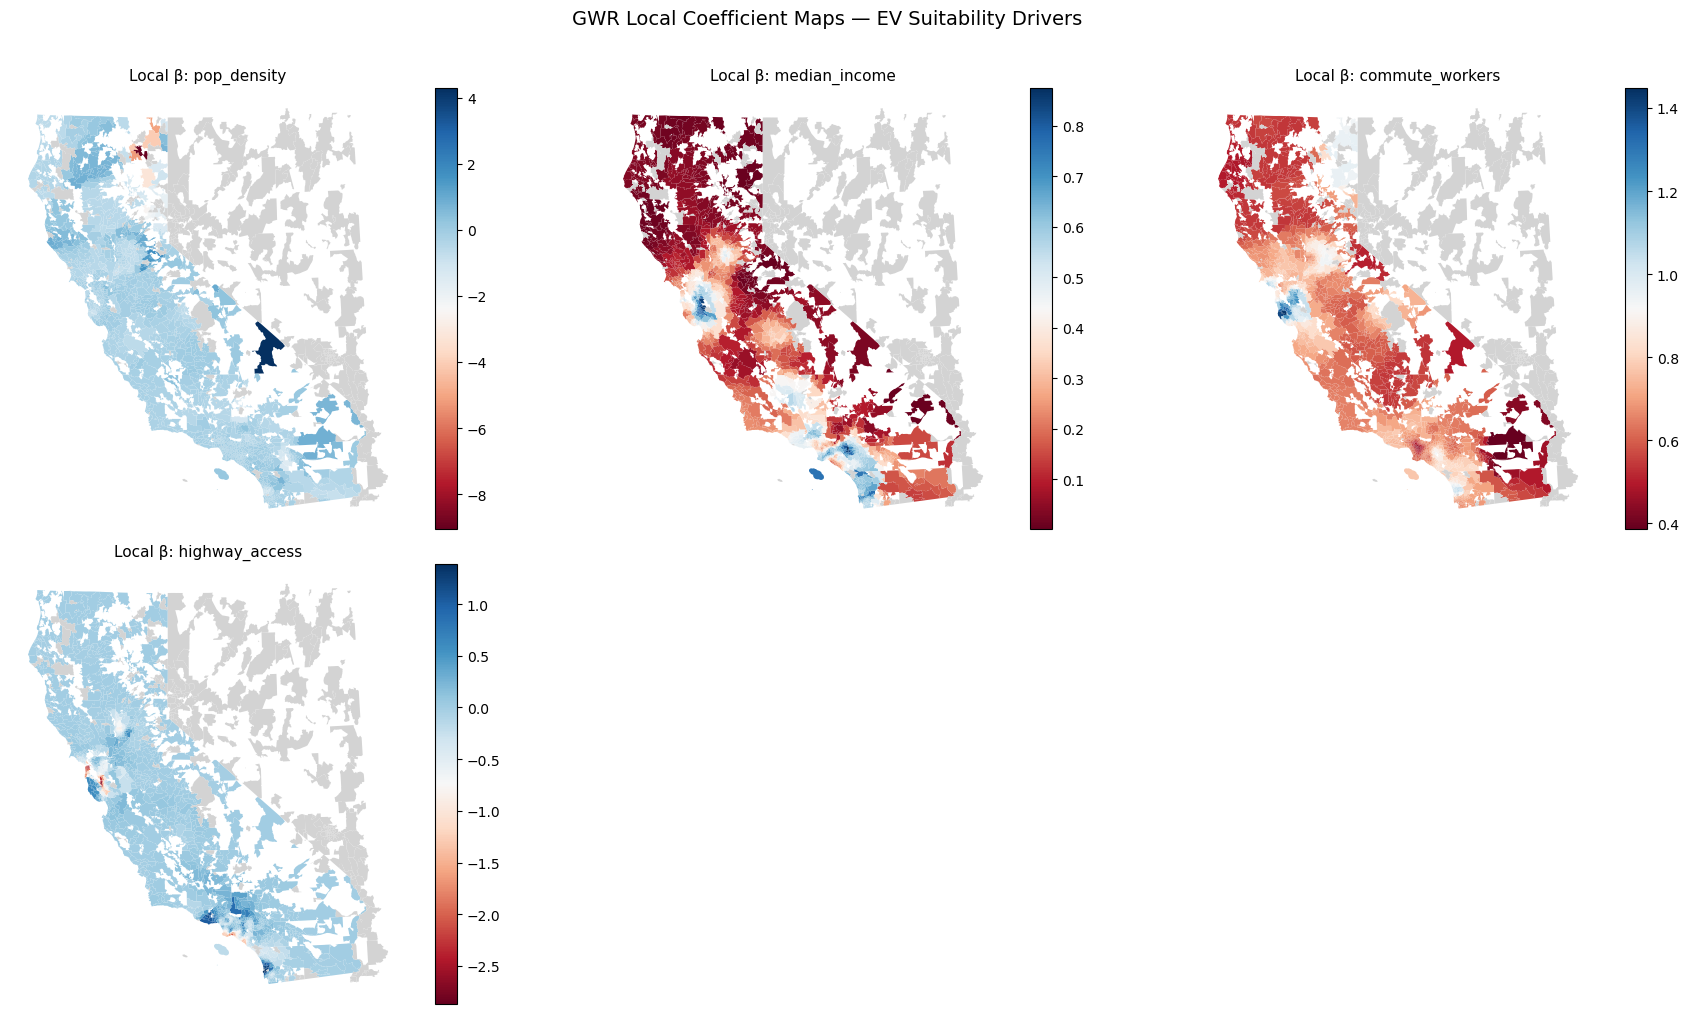

Saved: ./outputs/gwr_coefficient_maps.png


In [20]:
print(f'Fitting GWR with bandwidth={optimal_bw:.0f}...')

gwr_model = GWR(
    coords_gwr,
    y_gwr,
    X_gwr,
    bw=optimal_bw,
    kernel='bisquare',
    fixed=False,
    spherical=False,
)
gwr_results = gwr_model.fit()

def to_scalar(val):
    """Convert any numpy array or scalar to a Python float."""
    import numpy as np
    if isinstance(val, np.ndarray):
        return val.squeeze().item()
    return float(val)

# Report global model diagnostics 
print(f'\n=== GWR Model Diagnostics ===')
print(f'R² (global):          {to_scalar(gwr_results.R2):.4f}')
print(f'Adjusted R²:          {to_scalar(gwr_results.adj_R2):.4f}')


# AICc attribute name varies by mgwr version
aicc_val = getattr(gwr_results, 'AICc', None) \
        or getattr(gwr_results, 'aicc', None) \
        or getattr(gwr_results, 'aic', None)
print(f'AICc:                 {to_scalar(aicc_val):.2f}' if aicc_val is not None else 'AICc: N/A')

# RSS — sum of squared residuals (resid_response is the per-obs array)
rss = float(np.sum(gwr_results.resid_response ** 2))
print(f'Residual sum of sq:   {rss:.4f}')

# ENP — effective number of parameters (trace of hat matrix, scalar sum)
enp = float(np.sum(gwr_results.ENP))  if isinstance(gwr_results.ENP, np.ndarray) \
      else float(gwr_results.ENP)
print(f'Effective parameters: {enp:.1f}')

# sigma2 — if array, take mean; if scalar, use directly
s2 = float(np.mean(gwr_results.sigma2)) if isinstance(gwr_results.sigma2, np.ndarray) \
     else float(gwr_results.sigma2)
print(f'Sigma²:               {s2:.6f}')


# Per-ZCTA local results 
gwr_df['local_R2']     = gwr_results.localR2
gwr_df['gwr_residual'] = gwr_results.resid_response

# Use gwr_kept_cols — the features that survived variance filtering in 6.1
# params[:, 0] = intercept; params[:, 1:] = one column per kept feature
for i, feat in enumerate(gwr_kept_cols):
    gwr_df[f'coef_{feat}'] = gwr_results.params[:, i + 1]

print(f'\nLocal coefficients extracted for {len(gwr_kept_cols)} features')
print(f'   Features in model: {gwr_kept_cols}')
print(f'   Local R² range:    {gwr_df["local_R2"].min():.3f} – {gwr_df["local_R2"].max():.3f}')
print(f'   Mean local R²:     {gwr_df["local_R2"].mean():.3f}')

# Merge results back into full ZCTA GeoDataFrame 
coef_cols = [f'coef_{f}' for f in gwr_kept_cols]
zctas_gwr = zctas.merge(
    gwr_df[['zcta'] + coef_cols + ['local_R2', 'gwr_residual']],
    on='zcta', how='left'
)
print(f'\nzctas_gwr ready — {len(zctas_gwr):,} ZCTAs with GWR results attached')

# Plot local coefficient maps 
n_feats = len(gwr_kept_cols)
ncols   = 3
nrows   = (n_feats + ncols - 1) // ncols   # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for idx, feat in enumerate(gwr_kept_cols):
    col = f'coef_{feat}'
    zctas_gwr.plot(
        column=col,
        cmap='RdBu',
        legend=True,
        ax=axes[idx],
        missing_kwds={'color': 'lightgrey'}
    )
    axes[idx].set_title(f'Local β: {feat}', fontsize=11)
    axes[idx].axis('off')

# Hide unused subplots if feature count isn't divisible by ncols
for idx in range(n_feats, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('GWR Local Coefficient Maps — EV Suitability Drivers', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('./outputs/gwr_coefficient_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./outputs/gwr_coefficient_maps.png')

### 7.3 - Plot GWR Coefficient Maps

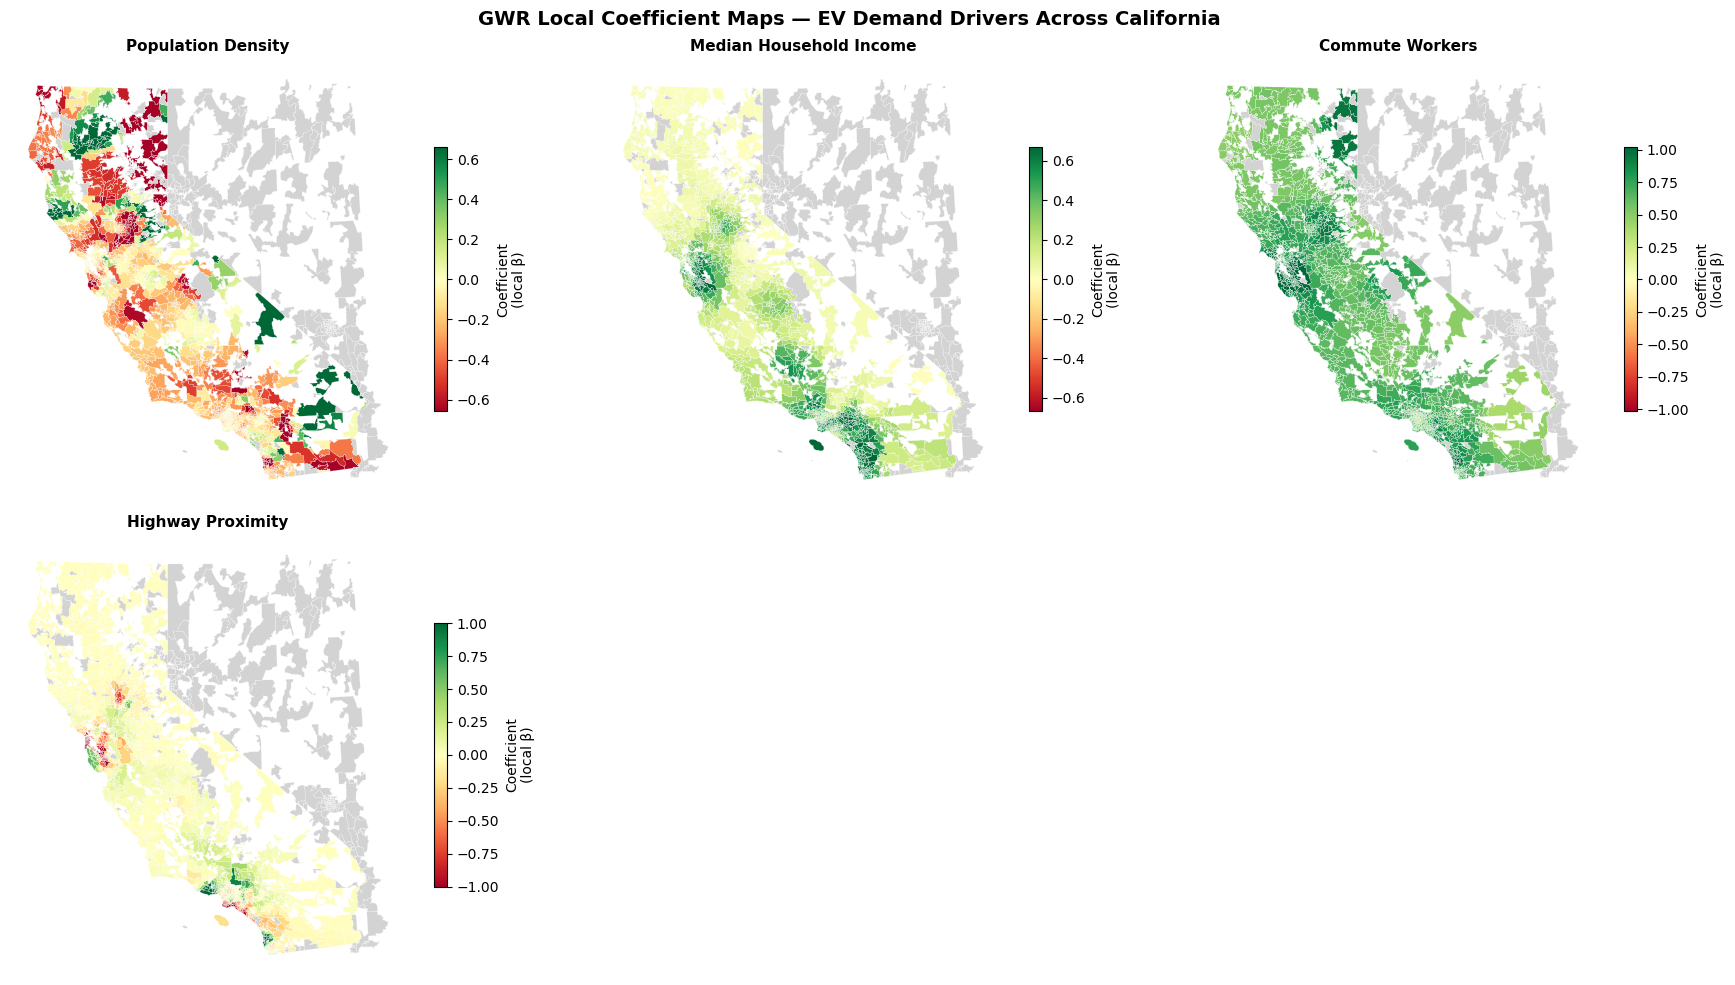

Saved: 05_gwr_coefficients.png — portfolio chart #5


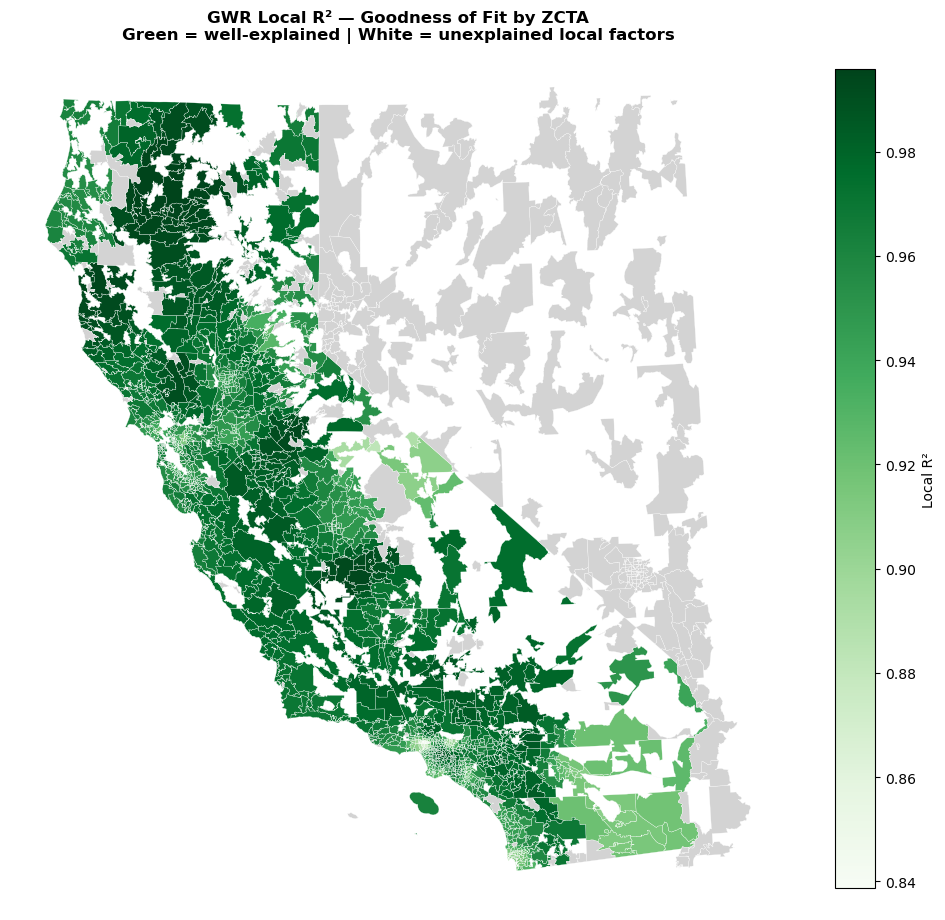

Saved: 06_gwr_local_r2.png — portfolio chart #6


In [21]:
# Merge GWR results back into the full ZCTA GeoDataFrame
# Uses gwr_kept_cols — only features that survived variance filtering in 6.1
zctas_gwr = zctas.merge(
    gwr_df[['zcta'] + [f'coef_{f}' for f in gwr_kept_cols] + ['local_R2', 'gwr_residual']],
    on='zcta', how='left'
)

# Build coef_labels dynamically from gwr_kept_cols
label_lookup = {
    'pop_density':       'Population Density',
    'median_income':      'Median Household Income',
    'commute_workers':    'Commute Workers',
    'highway_access':     'Highway Proximity',
    'retail_poi_density': 'Retail POI Density',
    'charger_gap_score':  'Charger Gap Score',
}
coef_labels = {f'coef_{f}': label_lookup.get(f, f) for f in gwr_kept_cols}

# Plot coefficient maps — dynamically sized to however many features survived
n_feats = len(coef_labels)
ncols   = 3
nrows   = (n_feats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
fig.suptitle('GWR Local Coefficient Maps — EV Demand Drivers Across California',
             fontsize=14, fontweight='bold', y=0.98)

for ax, (col, label) in zip(axes.flatten(), coef_labels.items()):
    vmax = max(abs(zctas_gwr[col].quantile(0.05)), abs(zctas_gwr[col].quantile(0.95)))
    zctas_gwr.plot(column=col, cmap='RdYlGn', ax=ax, legend=True,
                   vmin=-vmax, vmax=vmax,
                   legend_kwds={'label': 'Coefficient\n(local β)', 'shrink': 0.6},
                   edgecolor='white', linewidth=0.15,
                   missing_kwds={'color': 'lightgrey'})
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.axis('off')

# Hide unused subplots
for ax in axes.flatten()[n_feats:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('./outputs/05_gwr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: 05_gwr_coefficients.png — portfolio chart #5')

# Plot local R² map
fig, ax = plt.subplots(figsize=(10, 12))
zctas_gwr.plot(column='local_R2', cmap='Greens', ax=ax, legend=True,
               legend_kwds={'label': 'Local R²', 'shrink': 0.7},
               edgecolor='white', linewidth=0.2,
               missing_kwds={'color': 'lightgrey'})
ax.set_title('GWR Local R² — Goodness of Fit by ZCTA\nGreen = well-explained | White = unexplained local factors',
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('./outputs/06_gwr_local_r2.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: 06_gwr_local_r2.png — portfolio chart #6')

**Discussing GWR results in interviews:**

- The income coefficient varying from 0.8 in coastal LA to 0.2 in the Central Valley tells you: in wealthy coastal areas, income is a strong EV demand driver; in rural areas, income matters less because the decision is dominated by proximity to any chapter at all.
- The highway_access coefficient being strongest in inland California confirms that Interstate corridor charging (rather han destination charging) is the dominant unmet need in that region - a direct policy recommendation you can articulate to an interviewer.

## Step 8 - Suitability Map & Top-20 Candidate Sites

This step combines all the analysis into two final deliverables: an interactive Folium web map layering the existing charger network, the gap zones, and the MCE suitability scores - and a top-20 table of the highest-scoring underserved ZCCTAs that can go directly into a policy memo or briefing document.

### 8.1 - Build the Interactive Folium Suitability Map

In [ ]:
import json as _json

print('Building interactive EV suitability map...')

# Reproject to WGS84 for Folium — keep only columns needed for tooltips/styling
tooltip_cols = ['zcta', 'mce_score', 'pop_total', 'ev_registrations',
                'n_stations', 'is_gap', 'dist_to_coverage_m']

# Only keep columns that actually exist in the GeoDataFrame
tooltip_cols = [c for c in tooltip_cols if c in zctas.columns]

zctas_wgs = zctas[tooltip_cols + ['geometry']].to_crs('EPSG:4326')

# Convert via to_json() — safe for all column types
zctas_json     = _json.loads(zctas_wgs.to_json())

gap_zctas_wgs  = zctas_wgs[zctas_wgs['is_gap']]
gap_zctas_json = _json.loads(gap_zctas_wgs.to_json())

# Centre on California
m = folium.Map(location=[36.7783, -119.4179], zoom_start=6,
               tiles='CartoDB positron', attr='CartoDB')

# Layer 1: MCE Suitability choropleth 
from branca.colormap import LinearColormap
colorscale = LinearColormap(
    ['#FEF3C7', '#A7F3D0', '#059669', '#14532D'],
    vmin=zctas['mce_score'].min(),
    vmax=zctas['mce_score'].max(),
    caption='MCE Suitability Score (0=Low, 1=High)',
)

suitability_layer = folium.FeatureGroup(name='MCE Suitability Score', show=True)
folium.GeoJson(
    zctas_json,
    name='MCE Suitability',
    style_function=lambda f: {
        'fillColor': colorscale(f['properties'].get('mce_score') or 0),
        'fillOpacity': 0.65,
        'weight': 0.4,
        'color': 'white',
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[c for c in ['zcta', 'mce_score', 'pop_total',
                             'ev_registrations', 'n_stations'] if c in tooltip_cols],
        aliases=['ZCTA:', 'Suitability Score:', 'Population:',
                 'EV Registrations:', 'Current Stations:'],
        localize=True,
        sticky=False,
    ),
).add_to(suitability_layer)
suitability_layer.add_to(m)
colorscale.add_to(m)

# Layer 2: Gap zones 
gap_layer = folium.FeatureGroup(name='Underserved Gap Zones (>8km from cluster)', show=False)
folium.GeoJson(
    gap_zctas_json,
    style_function=lambda f: {
        'fillColor': '#DC2626',
        'fillOpacity': 0.35,
        'weight': 1.0,
        'color': '#991B1B',
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[c for c in ['zcta', 'pop_total', 'dist_to_coverage_m'] if c in tooltip_cols],
        aliases=['ZCTA:', 'Population:', 'Distance to nearest cluster (m):'],
    ),
).add_to(gap_layer)
gap_layer.add_to(m)

# Layer 3: Existing EV stations 
station_layer = folium.FeatureGroup(name='Existing EV Stations (AFDC)', show=False)
mc = MarkerCluster(options={'maxClusterRadius': 40, 'disableClusteringAtZoom': 12})
stations_wgs = stations_gdf.to_crs('EPSG:4326')
for _, row in stations_wgs.sample(min(3000, len(stations_wgs)), random_state=42).iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4, color='#059669', fill=True, fill_opacity=0.8,
        tooltip=f"{row['station_name']} | {row.get('ev_network', 'Unknown')} | {row['total_ports']:.0f} ports",
    ).add_to(mc)
mc.add_to(station_layer)
station_layer.add_to(m)

# Layer 4: Top-20 candidate sites 
top20_layer = folium.FeatureGroup(name='Top 20 Candidate Sites', show=True)
top20 = gap_zctas_wgs.nlargest(20, 'mce_score')
for rank, (_, row) in enumerate(top20.iterrows(), 1):
    centroid = row.geometry.centroid
    folium.Marker(
        location=[centroid.y, centroid.x],
        icon=folium.DivIcon(
            html=(f'<div style="background:#14532D;color:white;border-radius:50%;'
                  f'width:28px;height:28px;display:flex;align-items:center;'
                  f'justify-content:center;font-weight:bold;font-size:12px;'
                  f'border:2px solid white;">{rank}</div>'),
            icon_size=(28, 28), icon_anchor=(14, 14)
        ),
        tooltip=(f"Rank #{rank} | ZCTA {row['zcta']} | Score: {row['mce_score']:.3f} | "
                 f"Pop: {int(row['pop_total']):,} | EVs: {int(row['ev_registrations']):,}"),
    ).add_to(top20_layer)
top20_layer.add_to(m)

folium.LayerControl(position='topright', collapsed=False).add_to(m)
m.save('./outputs/06_ev_suitability_map.html')

print('Saved: 06_ev_suitability_map.html — portfolio output #6')
m

Building interactive EV suitability map...
Saved: 06_ev_suitability_map.html — portfolio output #6


### 8.2 - Generate the Top-20 Candidate Sites Report

In [22]:
# Build the top-20 ranked site table 
top20_report = (
    zctas[zctas['is_gap']]
    .nlargest(20, 'mce_score')
    [['zcta','mce_score','pop_total','pop_density','ev_registrations',
      'median_income','commute_workers','n_stations','dist_to_coverage_m']]
    .reset_index(drop=True)
)
top20_report.index = top20_report.index + 1  # 1-indexed ranking
top20_report.index.name = 'Rank'

# Format for display
top20_report['mce_score']          = top20_report['mce_score'].round(4)
top20_report['pop_total']          = top20_report['pop_total'].astype(int)
top20_report['ev_registrations']   = top20_report['ev_registrations'].astype(int)
top20_report['median_income']      = top20_report['median_income'].astype(int)
top20_report['dist_to_coverage_m'] = (top20_report['dist_to_coverage_m']/1000).round(1)

top20_report = top20_report.rename(columns={
    'zcta':'ZCTA','mce_score':'Score','pop_total':'Population',
    'pop_density':'Pop/km²','ev_registrations':'EV Regs',
    'median_income':'Med. Income','commute_workers':'Commuters',
    'n_stations':'Curr. Stations','dist_to_coverage_m':'Gap (km)',
})

print('\n=== TOP 20 CANDIDATE EV CHARGING SITES — CALIFORNIA ===')
print(top20_report.to_string())
top20_report.to_csv('./outputs/top20_candidate_sites.csv')
print('\nSaved: top20_candidate_sites.csv')


=== TOP 20 CANDIDATE EV CHARGING SITES — CALIFORNIA ===
       ZCTA   Score  Population     Pop/km²  EV Regs  Med. Income  Commuters  Curr. Stations  Gap (km)
Rank                                                                                                  
1     93536  0.5086       73417  111.065896     3303        89987    29627.0              10       8.9
2     93619  0.4591       48320   99.969725     2934       121444    21063.0               0       3.5
3     93306  0.4512       74518  293.760404     2267        60857    28511.0               3       3.9
4     93311  0.4417       48722   87.993500     2471       101447    21992.0              11       5.2
5     93117  0.4406       54915  124.725162     2140        77964    26925.0              34       1.5
6     93257  0.4374       78754   79.373558     1906        48411    30031.0              11       5.8
7     93535  0.4324       79522  128.430298     2050        51560    26979.0              15       3.7
8     95973  0.3